# Coffee Bean Defect Detector (Using Local Dataset)
## Coffee Quality Predictor — MODEL 3

This notebook trains a CNN from scratch to detect coffee bean defects.
We use the local coffee-bean-defect dataset, build a transfer-learning
model using MobileNetV2, train it locally, and export the .h5 file
for the FastAPI microservice.

## CELL 1 — Imports and dataset setup

Import TensorFlow/Keras and utilities.
Use the local coffee-bean-defect dataset.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import json, os, matplotlib.pyplot as plt


I0000 00:00:1782048044.139966   97042 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782048045.161052   97042 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782048053.883341   97042 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## CELL 2 — Inspect dataset structure

List the folders and count images per class.
This cell will show whether the dataset was loaded successfully.

In [2]:
base = os.path.abspath(os.path.join(os.getcwd(), "..", "coffee-bean-defect"))
split_base = os.path.join(base, 'split_data')

train_path = os.path.join(split_base, 'train')
val_path   = os.path.join(split_base, 'val')
test_path  = os.path.join(split_base, 'test')

print("\nFinal check:")
print(os.path.exists(train_path), os.path.exists(val_path), os.path.exists(test_path))


Final check:
True True True


## CELL 3 — Image data generators

Create training and validation generators with augmentation.
We use an 80/20 split.
NOTE: This cell requires the dataset to be present at data_path.

In [3]:
img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=True
)
val_data = val_gen.flow_from_directory(
    val_path, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

print("Classes found:", train_data.class_indices)
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")

Found 1005 images belonging to 9 classes.
Found 123 images belonging to 9 classes.
Classes found: {'black': 0, 'broken': 1, 'foreign': 2, 'fraghusk': 3, 'green': 4, 'husk': 5, 'immature': 6, 'infested': 7, 'sour': 8}
Training samples: 1005
Validation samples: 123


## CELL 4 — Build transfer learning model

Use MobileNetV2 pre-trained on ImageNet as the backbone.
Freeze the backbone and train only the new top layers.
Add dropout for regularization.

In [4]:
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

defect_model = Model(inputs=base_model.input, outputs=output)
defect_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)
defect_model.summary()

E0000 00:00:1782048058.730564   97042 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## CELL 5 — Train model

Train for up to 20 epochs with early stopping and model checkpoint.
Early stopping prevents overfitting.

In [5]:
checkpoint = ModelCheckpoint(
    'outputs/models/defect_detector.h5',
    monitor='val_accuracy', save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
)

history = defect_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/20


I0000 00:00:1782048062.044443   97042 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1782048068.730820   97355 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1782048068.846544   97355 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1782048068.968618   97355 cpu_allocator_impl.cc:82] Allocation of 154140672 exceeds 10% of free system memory.
W0000 00:00:1782048069.092749   97355 cpu_allocator_impl.cc:82] Allocation of 156905472 exceeds 10% of free system memory.
W0000 00:00:1782048069.147030   97355 cpu_allocator_impl.cc:82] Allocation of 38535168 exceeds 10% of free system memory.


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4595 - loss: 1.6982 - precision: 0.6212 - recall: 0.3077
Epoch 1: val_accuracy improved from None to 0.70732, saving model to outputs/models/defect_detector.h5



Epoch 1: finished saving model to outputs/models/defect_detector.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5950 - loss: 1.2649 - precision: 0.7285 - recall: 0.4458 - val_accuracy: 0.7073 - val_loss: 0.9003 - val_precision: 0.7387 - val_recall: 0.6667
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7452 - loss: 0.7663 - precision: 0.8122 - recall: 0.6658
Epoch 2: val_accuracy improved from 0.70732 to 0.75610, saving model to outputs/models/defect_detector.h5



Epoch 2: finished saving model to outputs/models/defect_detector.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7512 - loss: 0.7472 - precision: 0.8222 - recall: 0.6766 - val_accuracy: 0.7561 - val_loss: 0.6667 - val_precision: 0.8302 - val_recall: 0.7154
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7895 - loss: 0.6143 - precision: 0.8487 - recall: 0.7332
Epoch 3: val_accuracy improved from 0.75610 to 0.81301, saving model to outputs/models/defect_detector.h5



Epoch 3: finished saving model to outputs/models/defect_detector.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8030 - loss: 0.6053 - precision: 0.8591 - recall: 0.7463 - val_accuracy: 0.8130 - val_loss: 0.5513 - val_precision: 0.8692 - val_recall: 0.7561
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8074 - loss: 0.5760 - precision: 0.8689 - recall: 0.7464
Epoch 4: val_accuracy did not improve from 0.81301
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8060 - loss: 0.5828 - precision: 0.8709 - recall: 0.7453 - val_accuracy: 0.7724 - val_loss: 0.5701 - val_precision: 0.8491 - val_recall: 0.7317
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8040 - loss: 0.5468 - precision: 0.8803 - recall: 0.7460
Epoch 5: val_accuracy did not improve from 0.81301
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.8020 - loss: 0.5511 - precision: 0.8730 - recall: 0.7522 - val_accuracy: 0.8049 - val_loss: 0.5491 - val_precision: 0.8716 - val_recall: 0.772


Epoch 6: finished saving model to outputs/models/defect_detector.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8279 - loss: 0.5128 - precision: 0.8813 - recall: 0.7682 - val_accuracy: 0.8374 - val_loss: 0.5010 - val_precision: 0.9065 - val_recall: 0.7886
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8322 - loss: 0.4497 - precision: 0.8859 - recall: 0.7866
Epoch 7: val_accuracy did not improve from 0.83740
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8308 - loss: 0.4751 - precision: 0.8876 - recall: 0.7781 - val_accuracy: 0.8130 - val_loss: 0.5244 - val_precision: 0.8785 - val_recall: 0.7642
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8329 - loss: 0.4651 - precision: 0.9137 - recall: 0.7796
Epoch 8: val_accuracy did not improve from 0.83740
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8249 - loss: 0.4764 - precision: 0.9043 - recall: 0.7801 - val_accuracy: 0.8374 - val_loss: 0.4731 - val_precision: 0.9189 - val_recall: 0.829


Epoch 11: finished saving model to outputs/models/defect_detector.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8358 - loss: 0.4446 - precision: 0.9007 - recall: 0.7940 - val_accuracy: 0.8537 - val_loss: 0.4602 - val_precision: 0.9167 - val_recall: 0.8049
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8574 - loss: 0.3872 - precision: 0.9146 - recall: 0.8044
Epoch 12: val_accuracy did not improve from 0.85366
32/32 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.8537 - loss: 0.3959 - precision: 0.9060 - recall: 0.8060 - val_accuracy: 0.8374 - val_loss: 0.4761 - val_precision: 0.9065 - val_recall: 0.7886
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8512 - loss: 0.4094 - precision: 0.9312 - recall: 0.8118
Epoch 13: val_accuracy did not improve from 0.85366
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8498 - loss: 0.4083 - precision: 0.9094 - recall: 0.8090 - val_accuracy: 0.8211 - val_loss: 0.5358 - val_precision: 0.8716 - val_recall: 

## CELL 6 — Evaluate and plot accuracy

Plot training and validation accuracy curves.

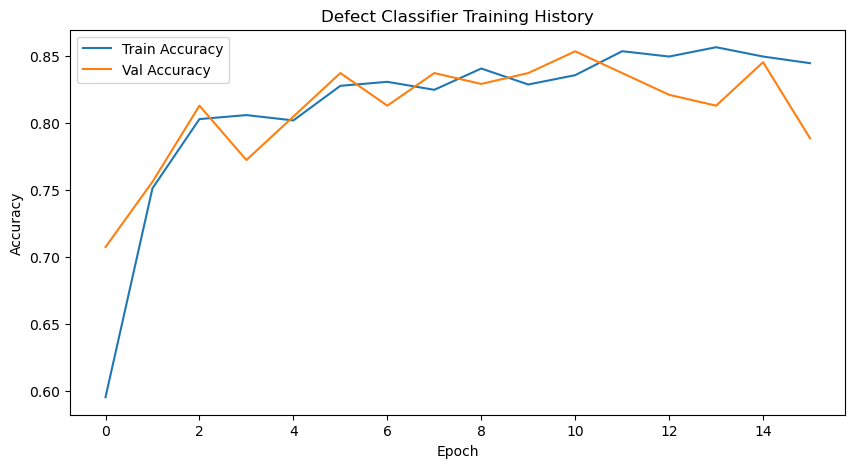

In [6]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Defect Classifier Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('outputs/charts/defect_training.png')
plt.show()

## CELL 7 — Predict on a new image (standalone example)

Load the saved .h5 model and run inference on a single image.
This mirrors what FastAPI will do at runtime.

In [7]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_defect(img_path, model, class_indices):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array, verbose=0)
    idx = int(np.argmax(preds[0]))
    confidence = float(preds[0][idx])
    # Reverse lookup: index -> class name
    class_names = {v: k for k, v in class_indices.items()}
    return class_names[idx], confidence

# Load saved model
loaded_model = tf.keras.models.load_model('outputs/models/defect_detector.h5')

# Test on a validation image
test_img_path = val_data.filepaths[0]
pred_class, pred_conf = predict_defect(test_img_path, loaded_model, train_data.class_indices)
print(f'Predicted defect: {pred_class}')
print(f'Confidence: {pred_conf*100:.1f}%')

Predicted defect: immature
Confidence: 42.5%


## CELL 8 — Export class labels

Save the class index mapping so FastAPI can decode predictions.

In [8]:
with open('outputs/models/defect_classes.json', 'w') as f:
    json.dump(train_data.class_indices, f, indent=2)
print("Saved defect_classes.json")
print("Classes:", train_data.class_indices)

Saved defect_classes.json
Classes: {'black': 0, 'broken': 1, 'foreign': 2, 'fraghusk': 3, 'green': 4, 'husk': 5, 'immature': 6, 'infested': 7, 'sour': 8}


##CELL 8 - Save result in reults_model3.txt

In [9]:
import numpy as np
import os

lines = []
def w(text=""):
    lines.append(str(text))

w("="*60)
w("MODEL 3: DEFECT DETECTOR (MobileNetV2 Transfer Learning)")
w("="*60)
w(f"Classes found: {train_data.class_indices}")
w(f"Number of classes: {len(train_data.class_indices)}")
w(f"Training images: {train_data.samples}")
w(f"Validation images: {val_data.samples}")
w(f"Image size: 224x224x3 | Batch size: 32")
w(f"Epochs trained (before early stop if triggered): {len(history.history['accuracy'])}")

w("")
w("ARCHITECTURE")
w("-"*60)
w("Base: MobileNetV2 (pretrained on ImageNet, frozen)")
w("Head: GlobalAveragePooling2D -> Dense(128, relu) -> Dropout(0.3) -> Dense(9, softmax)")
w("Optimizer: Adam | Loss: categorical_crossentropy")
w("Callbacks: ModelCheckpoint (best val_accuracy), EarlyStopping (patience=5)")

w("")
w("TRAINING HISTORY (per epoch)")
w("-"*60)
has_prec = 'precision' in history.history
header = f"{'Epoch':<8}{'Train Acc':<12}{'Val Acc':<12}{'Train Loss':<12}{'Val Loss':<12}"
if has_prec:
    header += f"{'Val Prec':<12}{'Val Recall':<12}"
w(header)
for i in range(len(history.history['accuracy'])):
    row = (f"{i+1:<8}{history.history['accuracy'][i]:<12.4f}"
           f"{history.history['val_accuracy'][i]:<12.4f}"
           f"{history.history['loss'][i]:<12.4f}"
           f"{history.history['val_loss'][i]:<12.4f}")
    if has_prec:
        # keys might be 'val_precision' or 'val_precision_1' etc depending on TF version
        prec_key = [k for k in history.history if k.startswith('val_precision')][0]
        rec_key = [k for k in history.history if k.startswith('val_recall')][0]
        row += f"{history.history[prec_key][i]:<12.4f}{history.history[rec_key][i]:<12.4f}"
    w(row)

w("")
w("FINAL / BEST RESULTS")
w("-"*60)
best_epoch = int(np.argmax(history.history['val_accuracy']))
w(f"Best Val Accuracy: {max(history.history['val_accuracy']):.4f} (epoch {best_epoch+1})")
w(f"Final Train Accuracy: {history.history['accuracy'][-1]:.4f}")
w(f"Final Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")
w(f"Final Train Loss: {history.history['loss'][-1]:.4f}")
w(f"Final Val Loss: {history.history['val_loss'][-1]:.4f}")

# Evaluate on the held-out TEST set (not just val) using class_names + test_path
try:
    from sklearn.metrics import classification_report, confusion_matrix
    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    test_gen = ImageDataGenerator(rescale=1./255)
    test_data = test_gen.flow_from_directory(
        test_path, target_size=(224,224), batch_size=32,
        class_mode='categorical', shuffle=False
    )
    preds = defect_model.predict(test_data)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_data.classes
    names = list(test_data.class_indices.keys())

    w("")
    w("CLASSIFICATION REPORT (on held-out TEST set)")
    w("-"*60)
    w(f"Test samples: {test_data.samples}")
    w(classification_report(y_true, y_pred, target_names=names))

    w("CONFUSION MATRIX (rows=true, cols=predicted)")
    w("-"*60)
    w(f"Classes order: {names}")
    w(str(confusion_matrix(y_true, y_pred)))
except Exception as e:
    w(f"(Could not generate test-set classification report: {e})")

# Per-class image counts (helps explain class imbalance issues)
try:
    w("")
    w("PER-CLASS IMAGE COUNTS (train/val/test)")
    w("-"*60)
    for cls in class_names:
        tr = len(os.listdir(os.path.join(train_path if 'train_path' in dir() else '', cls))) if 'train_path' in dir() else 'N/A'
    w("(see split print output from training cell for exact per-class counts)")
except Exception:
    pass

with open("results_model3.txt", "w") as f:
    f.write("\n".join(lines))

print("Saved to results_model3.txt")
print("Colab: from google.colab import files; files.download('results_model3.txt')")
print("Jupyter local: find results_model3.txt in your notebook's folder.")

Found 132 images belonging to 9 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step 
Saved to results_model3.txt
Colab: from google.colab import files; files.download('results_model3.txt')
Jupyter local: find results_model3.txt in your notebook's folder.


/home/natnael/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/natnael/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/natnael/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]